In [1]:
from build_everything import build_maskseg
from trainer import MaskSegTrainer
from models.maskseg import MaskSeg
from datasets.coco_lvis import LvisDataset
from utils.transforms import ResizeLongestSide

import torch
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

/home/clc/miniconda3/envs/var/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
maskseg = build_maskseg(
    vqvae_checkpoint_path="ckpt/vqvae_single.pth",
    sam_checkpoint_path="ckpt/sam_vit_b_01ec64.pth",
    )

In [3]:
optimizer = optim.Adam(maskseg.parameters(), lr=0.0001)
device = 'cuda'

In [4]:
trainer = MaskSegTrainer(maskseg, optimizer, device)

In [5]:
dataset = LvisDataset(
    dataset_path='data/coco_lvis',
    split='train',
    img_split='train',
    stuff_prob=0.0,
)

In [6]:
image, gt_mask, instance_info = dataset[10]

In [7]:
print(f'image shape: {image.shape}')
print(f'gt_mask shape: {gt_mask.shape}')
print(f'instance_info: {instance_info}')

image shape: (375, 500, 3)
gt_mask shape: (375, 500, 3)
instance_info: {0: InstanceInfo(mapping=(0, 9), parent=None, children=[], node_level=0), 1: InstanceInfo(mapping=(0, 8), parent=None, children=[], node_level=0), 2: InstanceInfo(mapping=(0, 7), parent=None, children=[], node_level=0), 3: InstanceInfo(mapping=(0, 10), parent=None, children=[], node_level=0), 4: InstanceInfo(mapping=(0, 5), parent=None, children=[], node_level=0), 5: InstanceInfo(mapping=(0, 12), parent=None, children=[], node_level=0), 6: InstanceInfo(mapping=(0, 11), parent=None, children=[], node_level=0), 7: InstanceInfo(mapping=(0, 13), parent=None, children=[], node_level=0), 8: InstanceInfo(mapping=(1, 1), parent=None, children=[], node_level=0), 9: InstanceInfo(mapping=(2, 1), parent=None, children=[], node_level=0), 10: InstanceInfo(mapping=(1, 3), parent=None, children=[], node_level=0), 11: InstanceInfo(mapping=(1, 2), parent=None, children=[], node_level=0)}


In [8]:
def resize_longest_side(image, target_length, mode='bilinear'):
    scale = target_length * 1.0 / max(image.shape[-2], image.shape[-1])
    newh, neww = image.shape[-2] * scale, image.shape[-1] * scale
    neww = int(neww + 0.5)
    newh = int(newh + 0.5)
    
    print(image.shape, (newh, neww))

    if mode == 'bilinear':
        return F.interpolate(
            image, (newh, neww), mode=mode, align_corners=False, antialias=True
        )
    else:
        return F.interpolate(
            image, (newh, neww), mode=mode,
        )

def preprocess_input(image, gt_mask, instance_info, instance_idx, device='cpu'):
    mask = gt_mask[:, :, instance_info[instance_idx].mapping[0]] == instance_info[instance_idx].mapping[1]
    print(mask.shape)

    # to tensor
    image = torch.from_numpy(image).to(device) / 255.0
    mask = torch.from_numpy(mask).to(device, dtype=torch.float32).unsqueeze(0)


    image = image.permute(2, 0, 1) # (H, W, 3) -> (3, H, W)
    image = resize_longest_side(image.unsqueeze(0), 1024).squeeze(0)
    mask = resize_longest_side(mask.unsqueeze(0), 256, 'nearest').squeeze(0)
    mask = mask.long()
    
    # normalize image
    image = image.permute(1, 2, 0) # (3, H, W) -> (H, W, 3)
    image = (image - trainer.pixel_mean) / trainer.pixel_std
    image = image.permute(2, 0, 1) # (H, W, 3) -> (3, H, W)

    # pad image to 1024
    h, w = image.shape[-2:]
    padh = 1024 - h
    padw = 1024 - w
    image = F.pad(image, (0, padw, 0, padh), value=0)

    # pad mask to 256
    h, w = mask.shape[-2:]
    padh = 256 - h
    padw = 256 - w
    mask = F.pad(mask, (0, padw, 0, padh), value=0)

    # normalize mask
    mask = mask * 2 - 1

    return image, mask


In [9]:
image, mask = preprocess_input(image, gt_mask, instance_info, 0, trainer.device)

(375, 500)
torch.Size([1, 3, 375, 500]) (768, 1024)
torch.Size([1, 1, 375, 500]) (192, 256)


In [10]:
image.shape

torch.Size([3, 1024, 1024])

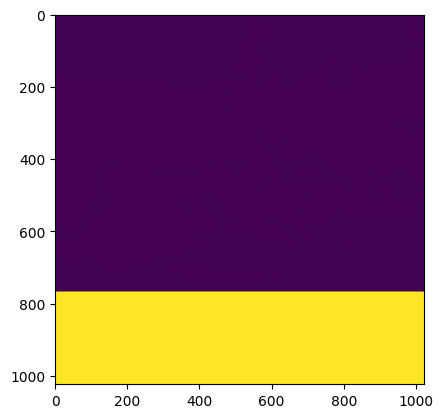

In [11]:
plt.imshow(image.cpu().numpy()[0, :, :])
plt.show()

In [12]:
image = image.unsqueeze(0)
mask = mask

In [13]:
print(f'image shape: {image.shape}')
print(f'mask shape: {mask.shape}')


image shape: torch.Size([1, 3, 1024, 1024])
mask shape: torch.Size([1, 256, 256])


In [14]:
trainer.forward_pass(image, mask)

RuntimeError: Given groups=1, weight of size [768, 3, 16, 16], expected input[1, 1024, 3, 1024] to have 3 channels, but got 1024 channels instead